In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("29-country_data.csv")

In [3]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [5]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [6]:
import math

def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols)/n_cols)

    plt.figure(figsize=(5*n_cols, 4*n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix} {col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

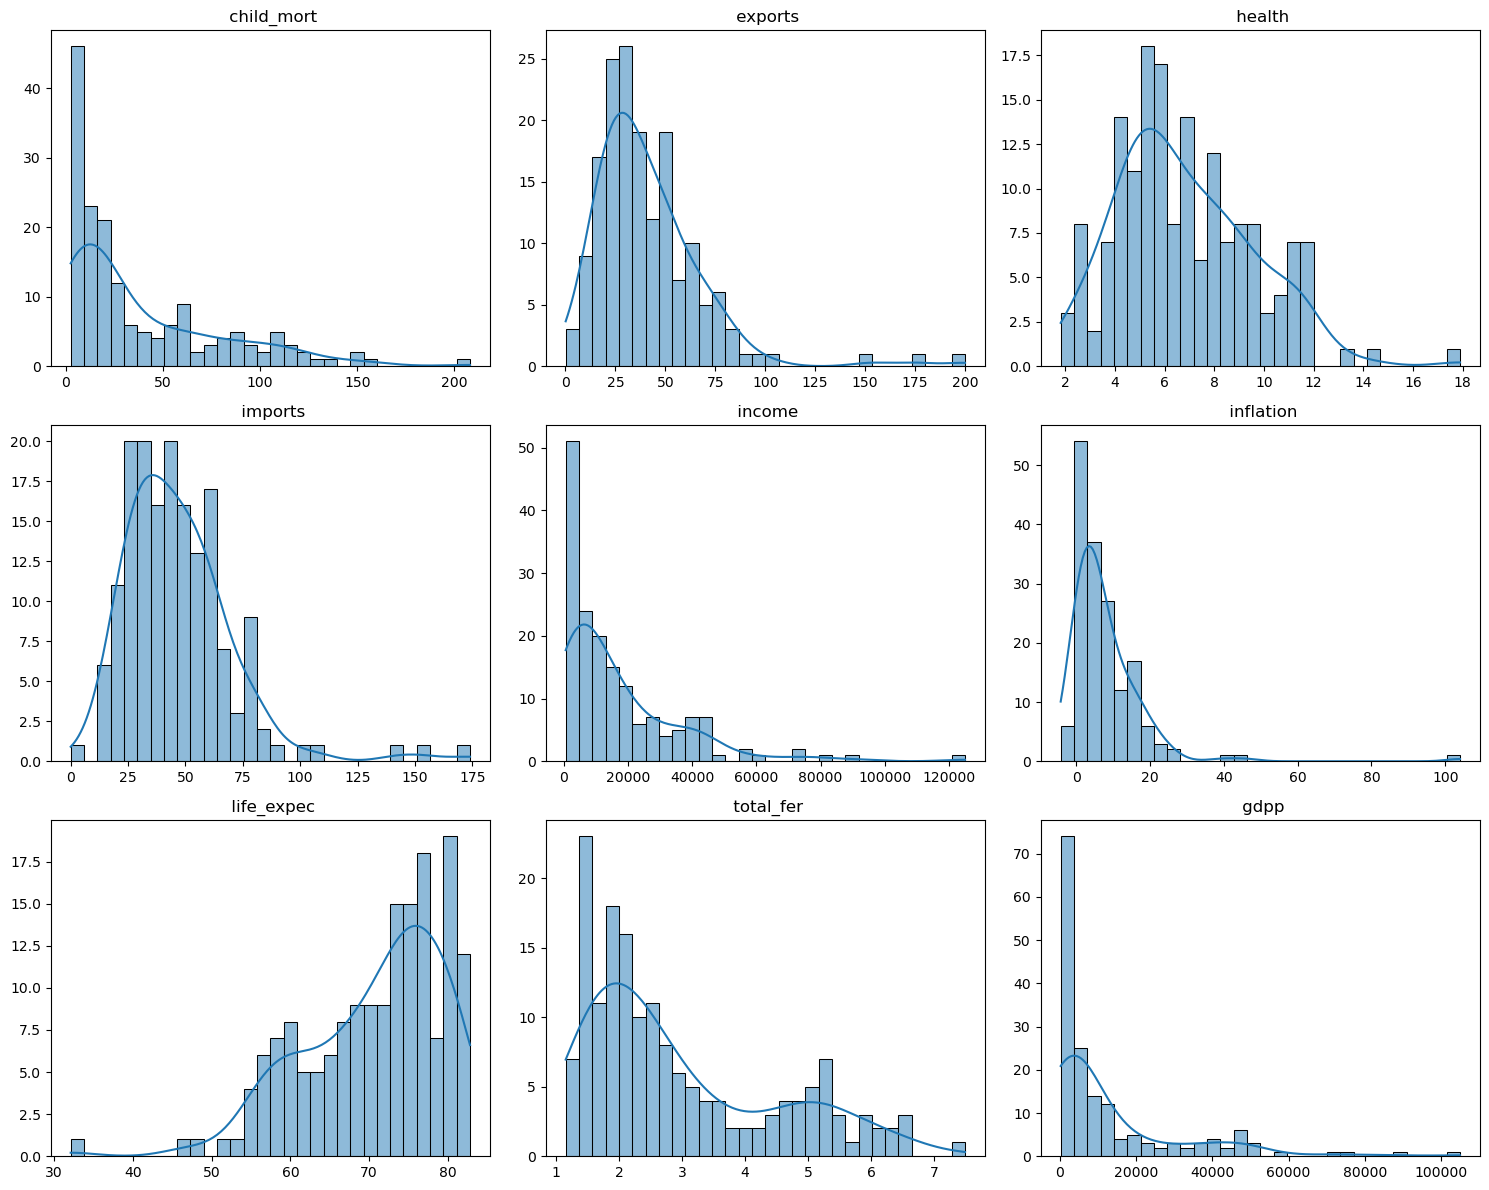

In [7]:
plot_all_histograms(df)

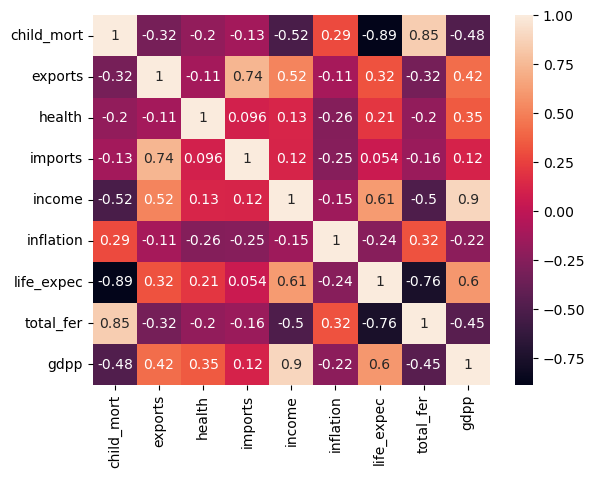

In [8]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [9]:
df2 = df.drop("country", axis=1)

In [10]:
df2.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [11]:
from sklearn.preprocessing import MinMaxScaler

In [12]:
scaler = MinMaxScaler()

In [13]:
df2 = scaler.fit_transform(df2)

In [14]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [15]:
df2 = pd.DataFrame(df2, columns=['child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'])

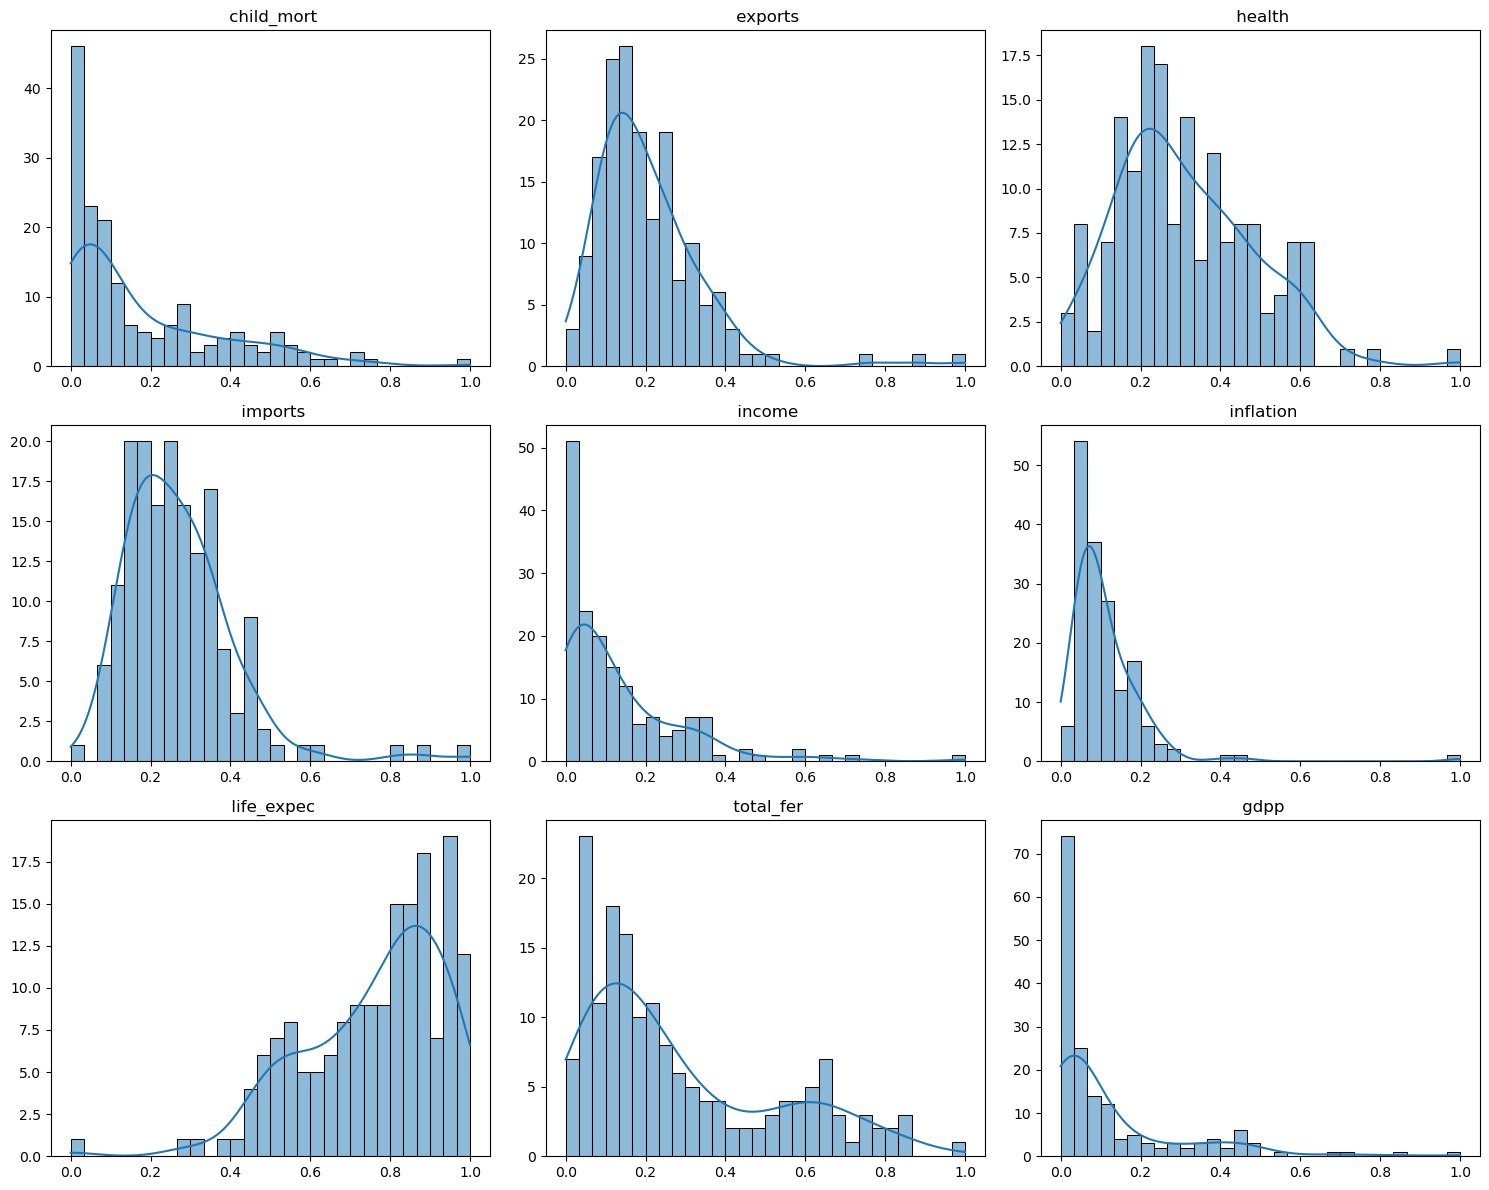

In [16]:
plot_all_histograms(df2)

In [17]:
from sklearn.decomposition import PCA 

In [18]:
pca = PCA()

In [19]:
pca_df2 = pd.DataFrame(pca.fit_transform(df2))

In [20]:
pca_df2

,0,1,2,3,4,5,6,7,8
0,0.599078,0.095490,0.157554,0.024333,0.045618,-0.046532,-0.076803,-0.040610,0.023572
1,-0.158474,-0.212092,-0.064189,0.061247,-0.014191,-0.010246,0.043567,-0.030842,0.029833
2,-0.003686,-0.135867,-0.134182,-0.133574,0.091150,0.025988,0.045604,0.010198,0.003012
3,0.650235,0.275975,-0.142672,-0.156018,0.081997,0.032170,0.073985,0.045195,-0.042241
4,-0.200711,-0.064662,-0.100715,0.037902,0.035799,-0.055817,0.009559,-0.026228,0.022455
...,...,...,...,...,...,...,...,...,...
162,0.160078,-0.029625,-0.121910,0.066099,0.009043,-0.063646,-0.115254,0.003232,-0.065701
163,-0.061133,-0.171339,-0.058586,-0.247460,0.093260,0.291515,-0.005521,-0.056038,-0.036459
164,-0.115512,-0.032034,-0.195243,0.231993,0.035734,0.089237,0.039743,0.006124,-0.017780
165,0.332968,-0.019824,-0.029989,-0.105416,0.141550,0.063254,-0.012519,-0.014231,-0.011441


In [21]:
pca.explained_variance_

array([0.14180615, 0.03450913, 0.03171502, 0.02513534, 0.00974048,
       0.00776992, 0.00306922, 0.00228894, 0.00178941])

In [22]:
pca.explained_variance_ratio_

array([0.55001227, 0.13384784, 0.12301053, 0.09749047, 0.03777964,
       0.03013659, 0.01190434, 0.00887791, 0.00694042])

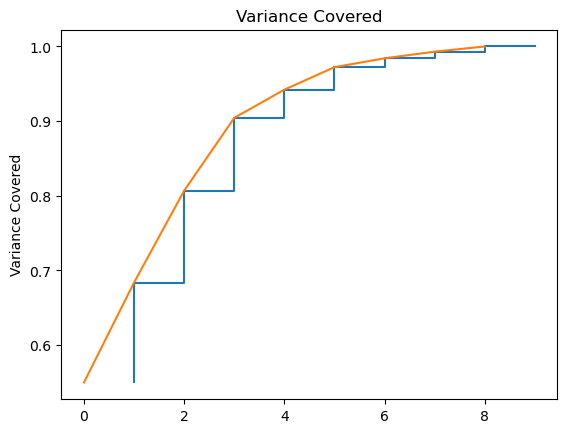

In [23]:
plt.step(list(range(1,10)),np.cumsum(pca.explained_variance_ratio_))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.ylabel("Variance Covered")
plt.title("Variance Covered")
plt.show()

In [24]:
pca_df2 = pca_df2.drop(columns=[3,4,5,6,7,8,])

In [25]:
pca_df2

,0,1,2
0,0.599078,0.095490,0.157554
1,-0.158474,-0.212092,-0.064189
2,-0.003686,-0.135867,-0.134182
3,0.650235,0.275975,-0.142672
4,-0.200711,-0.064662,-0.100715
...,...,...,...
162,0.160078,-0.029625,-0.121910
163,-0.061133,-0.171339,-0.058586
164,-0.115512,-0.032034,-0.195243
165,0.332968,-0.019824,-0.029989


In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [27]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(pca_df2)
    wcss.append(kmeans.inertia_)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

In [28]:
wcss

[34.533029253081764,
 17.684793618174393,
 11.2706222615415,
 9.81072163624186,
 7.229327464682717,
 6.855766269306452,
 5.363703787875825,
 4.666726860323773,
 4.4431732548375535,
 4.05388977722965]

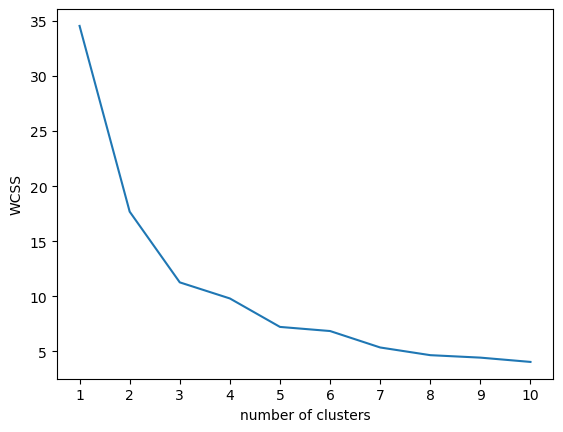

In [29]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("number of clusters")
plt.ylabel("WCSS")
plt.show()

In [30]:
model = KMeans(n_clusters=3)
model.fit(pca_df2)

C:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [31]:
labels = model.labels_

In [32]:
silhouette_score(pca_df2, labels)

0.4386320345236682

In [33]:
df["Class"] = labels

In [34]:
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Class
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2
...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,2
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,2
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,2
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,1


Text(0.5, 1.0, 'income vs class')

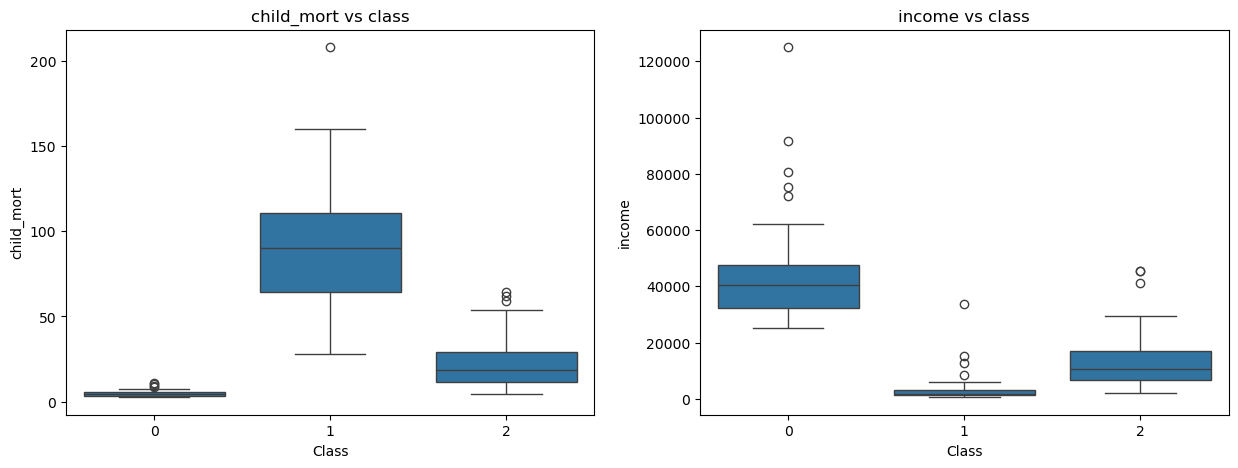

In [35]:
fig,ax = plt.subplots(nrows=1, ncols=2,figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=df, x="Class", y="child_mort")
plt.title("child_mort vs class")

plt.subplot(1,2,2)
sns.boxplot(data=df, x="Class", y="income")
plt.title("income vs class")

In [36]:
# 0 -> In Beetween
# 1 -> Budget Needed
# 2 -> No Budget Needed

In [37]:
import plotly.express as px

In [38]:
pca_df2.insert(0, column="Country", value=df["country"])

In [39]:
pca_df2["Class"] = labels

In [40]:
pca_df2.loc[pca_df2["Class"] == 0, "Class"] = "In Between"
pca_df2.loc[pca_df2["Class"] ==1, "Class"] = "Budget Needed"
pca_df2.loc[pca_df2["Class"]== 2, "Class"] = "No Budget Needed"

C:\Users\hp\AppData\Local\Temp\ipykernel_10880\2792710010.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'In Between' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  pca_df2.loc[pca_df2["Class"] == 0, "Class"] = "In Between"


In [41]:
pca_df2

,Country,0,1,2,Class
0,Afghanistan,0.599078,0.095490,0.157554,Budget Needed
1,Albania,-0.158474,-0.212092,-0.064189,No Budget Needed
2,Algeria,-0.003686,-0.135867,-0.134182,No Budget Needed
3,Angola,0.650235,0.275975,-0.142672,Budget Needed
4,Antigua and Barbuda,-0.200711,-0.064662,-0.100715,No Budget Needed
...,...,...,...,...,...
162,Vanuatu,0.160078,-0.029625,-0.121910,No Budget Needed
163,Venezuela,-0.061133,-0.171339,-0.058586,No Budget Needed
164,Vietnam,-0.115512,-0.032034,-0.195243,No Budget Needed
165,Yemen,0.332968,-0.019824,-0.029989,Budget Needed


In [42]:
data = pd.DataFrame([pca_df2.iloc[1]["Country"],pca_df2.iloc[2]["Country"]])
data

,0
0,Albania
1,Algeria


In [43]:
fig = px.choropleth(
    pca_df2[["Country","Class"]],
    locationmode = "country names",
    locations = "Country",
    title = "Needed Budget by Country",
    color = pca_df2["Class"],
    color_discrete_map = {
        "Budget Needed":"Red",
        "In Between": "Yellow",
        "No Budget Needed":"Green"
    }
)
fig.update_geos(fitbounds = "locations", visible=True)
fig.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_10880\811259359.py:1: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


In [44]:
pca = PCA()

In [45]:
pca_df = pd.DataFrame(pca.fit_transform(df2))

In [46]:
pca_df.head()

,0,1,2,3,4,5,6,7,8
0,0.599078,0.095490,0.157554,0.024333,0.045618,-0.046532,-0.076803,-0.040610,0.023572
1,-0.158474,-0.212092,-0.064189,0.061247,-0.014191,-0.010246,0.043567,-0.030842,0.029833
2,-0.003686,-0.135867,-0.134182,-0.133574,0.091150,0.025988,0.045604,0.010198,0.003012
3,0.650235,0.275975,-0.142672,-0.156018,0.081997,0.032170,0.073985,0.045195,-0.042241
4,-0.200711,-0.064662,-0.100715,0.037902,0.035799,-0.055817,0.009559,-0.026228,0.022455


Text(0, 0.5, 'Variance Covered')

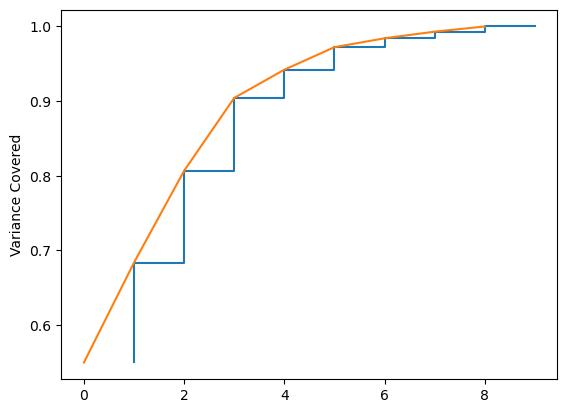

In [47]:
plt.step(range(1,10),np.cumsum(pca.explained_variance_ratio_))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title("")
plt.ylabel("Variance Covered")

In [48]:
pca_df.drop([3,4,5,6,7,8], axis=1, inplace=True)

In [49]:
pca_df.head()

,0,1,2
0,0.599078,0.095490,0.157554
1,-0.158474,-0.212092,-0.064189
2,-0.003686,-0.135867,-0.134182
3,0.650235,0.275975,-0.142672
4,-0.200711,-0.064662,-0.100715


In [50]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp', 'Class'],
      dtype='object')

In [51]:
from sklearn.cluster import DBSCAN,HDBSCAN,AgglomerativeClustering

In [52]:
from sklearn.metrics import calinski_harabasz_score,davies_bouldin_score,silhouette_score

In [53]:
models = [
    "DBSCAN",
    "HDBSCAN",
    "AgglomerativeClustering",
    "KMeans",
]

In [54]:
params={
    "DBSCAN":{
        "eps": [0.1,0.2,0.3,0.4,0.5,0.7,1,1.5],
        "min_samples":[2,3,4,5,6,7]
        } ,
     "HDBSCAN":{
        "min_cluster_size":[3,5,8,10,15],
         "min_samples":[None, 3,5,7]
        } ,
     "AgglomerativeClustering":{
        "n_clusters":[3],
         "linkage":["ward","complete","average"]
        } ,
     "KMeans":{
        "n_clusters":[3]
        } 
    
}

In [70]:
def training_models(data):
    dbscan_df =[]
    kmeans_df =[]
    hdbscan_df =[]
    agglomerative_clustering_df =[]
    modles_df=[]
    for name in models:
        if(name=="DBSCAN"):
            for eps in params["DBSCAN"]["eps"]:
                for min_sample in params["DBSCAN"]["min_samples"]:
                    model = DBSCAN(eps=eps, min_samples=min_sample).fit(data)
                    labels = model.labels_
                    if len(set(labels))<=1:
                        continue
                    dbscan_df.append(
                        {
                            "Model Name": name,
                            "eps":eps,
                            "min_samples" : min_sample,
                            "Silhouette":silhouette_score(data, labels),
                            "Calinski Harabasz Score":calinski_harabasz_score(data, labels),
                            "Davies Bouldin Score":davies_bouldin_score(data, labels)
                        }
                    )
            dbscan_df = pd.DataFrame(dbscan_df).sort_values(by="Silhouette", ascending=False)
    
        elif(name=="HDBSCAN"):
            for min_cluster_size in params["HDBSCAN"]["min_cluster_size"]:
                for min_sample in params["HDBSCAN"]["min_samples"]:
                    model = HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_sample).fit(data)
                    labels = model.labels_
                    if len(set(labels))<=1:
                        continue
                    hdbscan_df.append(
                        {
                            "Model Name": name,
                            "min_cluster_size":min_cluster_size,
                            "min_samples" : min_sample,
                            "Silhouette":silhouette_score(data, labels),
                            "Calinski Harabasz Score":calinski_harabasz_score(data, labels),
                            "Davies Bouldin Score":davies_bouldin_score(data, labels)
                        }
                    )
            hdbscan_df = pd.DataFrame(hdbscan_df).sort_values(by="Silhouette", ascending=False)
           
        elif(name=="AgglomerativeClustering"):
            for n_cluster in params["AgglomerativeClustering"]["n_clusters"]:
                for linkage in params["AgglomerativeClustering"]["linkage"]:
                    model = AgglomerativeClustering(n_clusters=n_cluster, linkage=linkage).fit(data)
                    labels = model.labels_
                    if len(set(labels))<=1:
                        continue
                    agglomerative_clustering_df.append(
                        {
                            "Model Name": name,
                            "n_clusters" : n_cluster,
                            "linkage" : linkage,
                            "Silhouette":silhouette_score(data, labels),
                            "Calinski Harabasz Score":calinski_harabasz_score(data, labels),
                            "Davies Bouldin Score":davies_bouldin_score(data, labels)
                        }
                    )
            agglomerative_clustering_df = pd.DataFrame(agglomerative_clustering_df).sort_values(by="Silhouette", ascending=False)
        
        elif(name=="KMeans"):
            for n_cluster in params["KMeans"]["n_clusters"]:
                model = KMeans(n_clusters=n_cluster).fit(data)
                labels = model.labels_
                if len(set(labels))<=1:
                        continue
                kmeans_df.append(
                    {
                        "Model Name": name,
                        "n_clusters" : n_cluster,
                        "Silhouette":silhouette_score(data, labels),
                        "Calinski Harabasz Score":calinski_harabasz_score(data, labels),
                        "Davies Bouldin Score":davies_bouldin_score(data, labels)
                    }
                )
            kmeans_df = pd.DataFrame(kmeans_df).sort_values(by="Silhouette", ascending=False)
         
    models_df = pd.DataFrame([
        dbscan_df.iloc[0][["Model Name","Silhouette","Calinski Harabasz Score"]],
        hdbscan_df.iloc[0][["Model Name","Silhouette","Calinski Harabasz Score"]],
        agglomerative_clustering_df.iloc[0][["Model Name","Silhouette","Calinski Harabasz Score"]],
        kmeans_df.iloc[0][["Model Name","Silhouette","Calinski Harabasz Score"]],
        
    ], columns=["Model Name","Silhouette","Calinski Harabasz Score"]).sort_values(by="Silhouette", ascending=False)
    return dbscan_df,hdbscan_df,agglomerative_clustering_df,kmeans_df,models_df

In [71]:
import warnings
warnings.filterwarnings("ignore")

In [72]:
df2.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,0.426485,0.049482,0.358608,0.257765,0.008047,0.126144,0.475345,0.736593,0.003073
1,0.068160,0.139531,0.294593,0.279037,0.074933,0.080399,0.871795,0.078864,0.036833
2,0.120253,0.191559,0.146675,0.180149,0.098809,0.187691,0.875740,0.274448,0.040365
3,0.566699,0.311125,0.064636,0.246266,0.042535,0.245911,0.552268,0.790221,0.031488
4,0.037488,0.227079,0.262275,0.338255,0.148652,0.052213,0.881657,0.154574,0.114242


In [73]:
df2.corr()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
child_mort,1.000000,-0.318093,-0.200402,-0.127211,-0.524315,0.288276,-0.886676,0.848478,-0.483032
exports,-0.318093,1.000000,-0.114408,0.737381,0.516784,-0.107294,0.316313,-0.320011,0.418725
health,-0.200402,-0.114408,1.000000,0.095717,0.129579,-0.255376,0.210692,-0.196674,0.345966
imports,-0.127211,0.737381,0.095717,1.000000,0.122406,-0.246994,0.054391,-0.159048,0.115498
income,-0.524315,0.516784,0.129579,0.122406,1.000000,-0.147756,0.611962,-0.501840,0.895571
inflation,0.288276,-0.107294,-0.255376,-0.246994,-0.147756,1.000000,-0.239705,0.316921,-0.221631
life_expec,-0.886676,0.316313,0.210692,0.054391,0.611962,-0.239705,1.000000,-0.760875,0.600089
total_fer,0.848478,-0.320011,-0.196674,-0.159048,-0.501840,0.316921,-0.760875,1.000000,-0.454910
gdpp,-0.483032,0.418725,0.345966,0.115498,0.895571,-0.221631,0.600089,-0.454910,1.000000


In [74]:
# export import, income gdpp, life expec child mort total_fer, inflation,health

In [75]:
df_feature_extracted = df2.copy()

In [76]:
df_feature_extracted2 = df2.copy()

In [77]:
df_feature_extracted["releated_health"] = df_feature_extracted["life_expec"]+df_feature_extracted["health"]-df_feature_extracted["child_mort"]-df_feature_extracted["total_fer"]
df_feature_extracted["releated_economic"] = (df_feature_extracted["income"])/(df_feature_extracted["gdpp"] + 1e-6 )
df_feature_extracted["releated_inflation"] = (df_feature_extracted["inflation"])/(df_feature_extracted["gdpp"] + 1e-6 )
df_feature_extracted["releated_trading"] = df_feature_extracted["exports"]-df_feature_extracted["imports"]

In [78]:
df_feature_extracted.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,releated_health,releated_economic,releated_inflation,releated_trading
0,0.426485,0.049482,0.358608,0.257765,0.008047,0.126144,0.475345,0.736593,0.003073,-0.329125,2.617464,41.029942,-0.208283
1,0.068160,0.139531,0.294593,0.279037,0.074933,0.080399,0.871795,0.078864,0.036833,1.019364,2.034322,2.182720,-0.139506
2,0.120253,0.191559,0.146675,0.180149,0.098809,0.187691,0.875740,0.274448,0.040365,0.627713,2.447838,4.649721,0.011410
3,0.566699,0.311125,0.064636,0.246266,0.042535,0.245911,0.552268,0.790221,0.031488,-0.740015,1.350783,7.809337,0.064858
4,0.037488,0.227079,0.262275,0.338255,0.148652,0.052213,0.881657,0.154574,0.114242,0.951870,1.301196,0.457038,-0.111176


In [79]:
df_feature_extracted.drop(["exports","imports","income","gdpp","life_expec","child_mort","total_fer","inflation","health"],axis=1,inplace=True)

In [80]:
df_feature_extracted.head()

,releated_health,releated_economic,releated_inflation,releated_trading
0,-0.329125,2.617464,41.029942,-0.208283
1,1.019364,2.034322,2.182720,-0.139506
2,0.627713,2.447838,4.649721,0.011410
3,-0.740015,1.350783,7.809337,0.064858
4,0.951870,1.301196,0.457038,-0.111176


In [81]:
df_feature_extracted.corr()

,releated_health,releated_economic,releated_inflation,releated_trading
releated_health,1.000000,-0.094731,-0.092929,0.182840
releated_economic,-0.094731,1.000000,0.999973,-0.091140
releated_inflation,-0.092929,0.999973,1.000000,-0.091312
releated_trading,0.182840,-0.091140,-0.091312,1.000000


In [82]:
scaler = MinMaxScaler()
df_feature_extracted = scaler.fit_transform(df_feature_extracted)

In [83]:
df_feature_extracted =pd.DataFrame(df_feature_extracted, columns=["releated_health","releated_economic","releated_inflation","releated_trading"])

In [84]:
dbscan_df_fe,hdbscan_df_fe,agglomerative_clustering_df_fe,kmeans_df_fe,models_df_fe = training_models(df_feature_extracted)

In [85]:
dbscan_df_pca,hdbscan_df_pca,agglomerative_clustering_df_pca,kmeans_df_pca,models_pca_df = training_models(pca_df)

In [86]:
dbscan_df,hdbscan_df,agglomerative_clustering_df,kmeans_df,models_df = training_models(df2)

In [87]:
models_df_fe

,Model Name,Silhouette,Calinski Harabasz Score
21,DBSCAN,0.763731,27.028522
2,AgglomerativeClustering,0.459232,88.294583
0,KMeans,0.429432,101.575988
17,HDBSCAN,0.306001,35.030604


In [88]:
models_pca_df

,Model Name,Silhouette,Calinski Harabasz Score
29,DBSCAN,0.599196,18.250805
2,AgglomerativeClustering,0.460232,118.892492
0,KMeans,0.438632,169.246855
9,HDBSCAN,0.240060,38.582332


In [89]:
agglomerative_clustering_df_fe.head()

,Model Name,n_clusters,linkage,Silhouette,Calinski Harabasz Score,Davies Bouldin Score
2,AgglomerativeClustering,3,average,0.459232,88.294583,0.536577
0,AgglomerativeClustering,3,ward,0.457554,94.316137,0.663549
1,AgglomerativeClustering,3,complete,0.420267,74.660650,0.702697


In [90]:
dbscan_df_fe.head()

,Model Name,eps,min_samples,Silhouette,Calinski Harabasz Score,Davies Bouldin Score
21,DBSCAN,0.4,5,0.763731,27.028522,0.169932
22,DBSCAN,0.4,6,0.763731,27.028522,0.169932
24,DBSCAN,0.5,2,0.763731,27.028522,0.169932
25,DBSCAN,0.5,3,0.763731,27.028522,0.169932
26,DBSCAN,0.5,4,0.763731,27.028522,0.169932
